1. Imports

In [23]:

import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

2. Dataset Paths

In [24]:

base_path = "../data"

train_dir = os.path.join(base_path, "train")
valid_dir = os.path.join(base_path, "valid")
test_dir = os.path.join(base_path, "test")

print("Train:", train_dir)
print("Valid:", valid_dir)
print("Test:", test_dir)

print("Train classes:", os.listdir(train_dir))
print("Valid classes:", os.listdir(valid_dir))
print("Test classes:", os.listdir(test_dir))

Train: ../data\train
Valid: ../data\valid
Test: ../data\test
Train classes: ['0', '1']
Valid classes: ['0', '1']
Test classes: ['0', '1']



3. Transforms

In [25]:

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(7),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

valid_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

4. Dataset

In [26]:

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=valid_test_transforms)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))
print("Test size:", len(test_dataset))

Classes: ['0', '1']
Class mapping: {'0': 0, '1': 1}
Train size: 8554
Valid size: 1070
Test size: 1070


5. DataLoader

In [27]:

batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train batches: 1070
Valid batches: 134
Test batches: 134


6. Device

In [28]:

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cpu


7. EfficientNet-B0 Model

In [29]:

efficientnet_model = models.efficientnet_b0(weights=None)

efficientnet_model.features[0][0] = nn.Conv2d(
    1,
    32,
    kernel_size=3,
    stride=2,
    padding=1,
    bias=False
)

efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_model.classifier[1].in_features,
    2
)

efficientnet_model = efficientnet_model.to(device)

print("EfficientNet-B0 model is ready.")

EfficientNet-B0 model is ready.


8. Loss + Optimizer + Epoch

In [30]:

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    efficientnet_model.parameters(),
    lr=0.0001
)

num_epochs = 5

9. Train Function

In [31]:

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

10. Validate Function


In [32]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

11. Training Code 

In [33]:

efficientnet_train_losses = []
efficientnet_valid_losses = []

efficientnet_train_accuracies = []
efficientnet_valid_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        efficientnet_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate(
        efficientnet_model,
        valid_loader,
        criterion,
        device
    )

    efficientnet_train_losses.append(train_loss)
    efficientnet_valid_losses.append(valid_loss)

    efficientnet_train_accuracies.append(train_acc)
    efficientnet_valid_accuracies.append(valid_acc)

    print(f"\nEfficientNet-B0 Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Accuracy: {valid_acc:.2f}%")


EfficientNet-B0 Epoch [1/5]
Train Loss: 0.6254
Train Accuracy: 64.38%
Valid Loss: 0.4178
Valid Accuracy: 79.07%

EfficientNet-B0 Epoch [2/5]
Train Loss: 0.4791
Train Accuracy: 77.12%
Valid Loss: 0.3800
Valid Accuracy: 82.90%

EfficientNet-B0 Epoch [3/5]
Train Loss: 0.4246
Train Accuracy: 81.11%
Valid Loss: 0.3135
Valid Accuracy: 85.70%

EfficientNet-B0 Epoch [4/5]
Train Loss: 0.3777
Train Accuracy: 83.94%
Valid Loss: 0.2809
Valid Accuracy: 88.50%

EfficientNet-B0 Epoch [5/5]
Train Loss: 0.3538
Train Accuracy: 84.91%
Valid Loss: 0.2729
Valid Accuracy: 87.66%


12. Training Result Table

In [34]:

training_results_df = pd.DataFrame({
    "Epoch": list(range(1, num_epochs + 1)),
    "Train Loss": efficientnet_train_losses,
    "Validation Loss": efficientnet_valid_losses,
    "Train Accuracy": efficientnet_train_accuracies,
    "Validation Accuracy": efficientnet_valid_accuracies
})

training_results_df

,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy
0,1,0.625400,0.417779,64.379238,79.065421
1,2,0.479081,0.379969,77.121814,82.897196
2,3,0.424558,0.313471,81.108253,85.700935
3,4,0.377667,0.280912,83.937339,88.504673
4,5,0.353847,0.272946,84.907646,87.663551


13. Training Graph

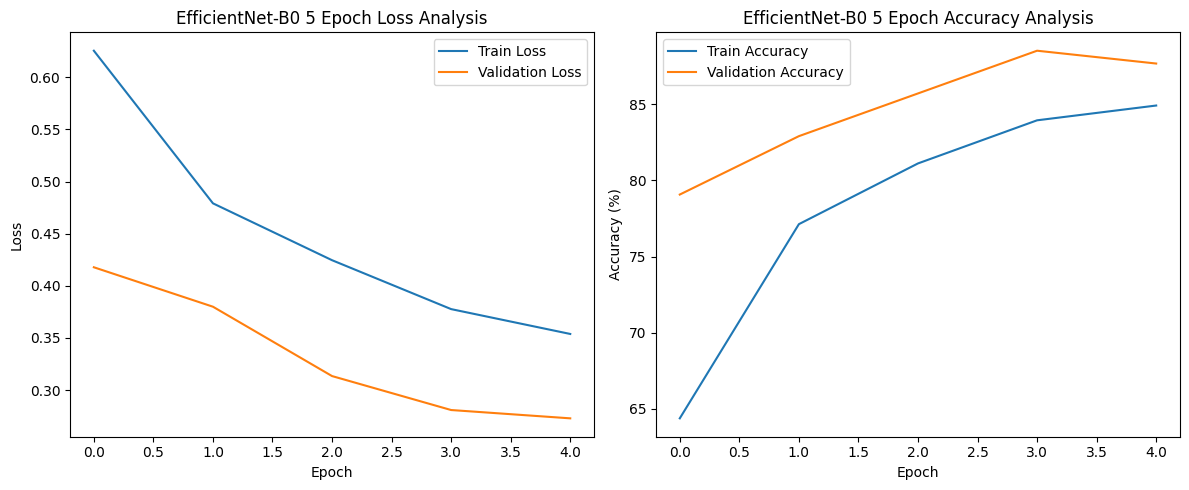

In [35]:

os.makedirs("../outputs", exist_ok=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(efficientnet_train_losses, label="Train Loss")
plt.plot(efficientnet_valid_losses, label="Validation Loss")
plt.title(f"EfficientNet-B0 {num_epochs} Epoch Loss Analysis")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(efficientnet_train_accuracies, label="Train Accuracy")
plt.plot(efficientnet_valid_accuracies, label="Validation Accuracy")
plt.title(f"EfficientNet-B0 {num_epochs} Epoch Accuracy Analysis")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.savefig(f"../outputs/efficientnet_b0_training_analysis_{num_epochs}epoch.png")
plt.show()

14. Save Model — Eğitim Çalıştırdıysan Kullan

In [36]:

os.makedirs("../models", exist_ok=True)

torch.save(
    efficientnet_model.state_dict(),
    f"../models/efficientnet_b0_chest_xray_{num_epochs}epoch.pth"
)

print(f"EfficientNet-B0 {num_epochs} epoch model saved successfully.")

EfficientNet-B0 5 epoch model saved successfully.


15. Load Saved Model — Buradan Sonrasını Çalıştır

In [37]:

efficientnet_model = models.efficientnet_b0(weights=None)

efficientnet_model.features[0][0] = nn.Conv2d(
    1,
    32,
    kernel_size=3,
    stride=2,
    padding=1,
    bias=False
)

efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_model.classifier[1].in_features,
    2
)

model_path = f"../models/efficientnet_b0_chest_xray_{num_epochs}epoch.pth"

if num_epochs == 5 and not os.path.exists(model_path):
    model_path = "../models/efficientnet_b0_chest_xray.pth"

efficientnet_model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

efficientnet_model = efficientnet_model.to(device)
efficientnet_model.eval()

print(f"Loaded model: {model_path}")

Loaded model: ../models/efficientnet_b0_chest_xray_5epoch.pth


16. Test Evaluation

In [38]:

efficientnet_all_labels = []
efficientnet_all_preds = []
efficientnet_all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        efficientnet_all_probs.extend(probs[:, 1].cpu().numpy())
        efficientnet_all_preds.extend(preds.cpu().numpy())
        efficientnet_all_labels.extend(labels.cpu().numpy())

efficientnet_all_probs = np.array(efficientnet_all_probs)
efficientnet_all_preds = np.array(efficientnet_all_preds)
efficientnet_all_labels = np.array(efficientnet_all_labels)

print("EfficientNet-B0 evaluation completed.")

EfficientNet-B0 evaluation completed.


17. Metrics

In [39]:

efficientnet_accuracy = accuracy_score(efficientnet_all_labels, efficientnet_all_preds)
efficientnet_precision = precision_score(efficientnet_all_labels, efficientnet_all_preds)
efficientnet_recall = recall_score(efficientnet_all_labels, efficientnet_all_preds)
efficientnet_f1 = f1_score(efficientnet_all_labels, efficientnet_all_preds)
efficientnet_auc = roc_auc_score(efficientnet_all_labels, efficientnet_all_probs)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Value": [
        efficientnet_accuracy,
        efficientnet_precision,
        efficientnet_recall,
        efficientnet_f1,
        efficientnet_auc
    ]
})

metrics_df

,Metric,Value
0,Accuracy,0.887850
1,Precision,0.948164
2,Recall,0.820561
3,F1-Score,0.879760
4,ROC-AUC,0.966401


18. Confusion Matrix

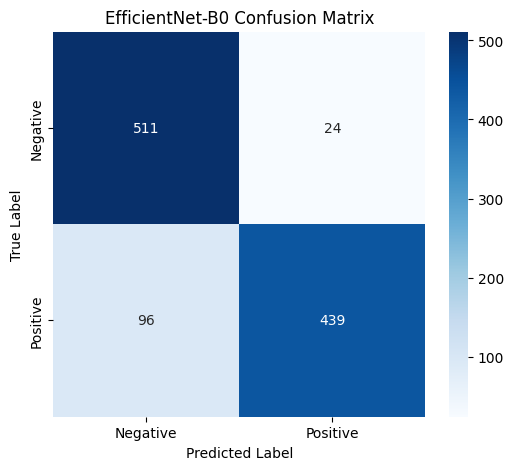

TN: 511
FP: 24
FN: 96
TP: 439


In [40]:

cm = confusion_matrix(
    efficientnet_all_labels,
    efficientnet_all_preds
)

tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNet-B0 Confusion Matrix")

plt.savefig(f"../outputs/efficientnet_b0_confusion_matrix_{num_epochs}epoch.png")
plt.show()

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

19. ROC Curve

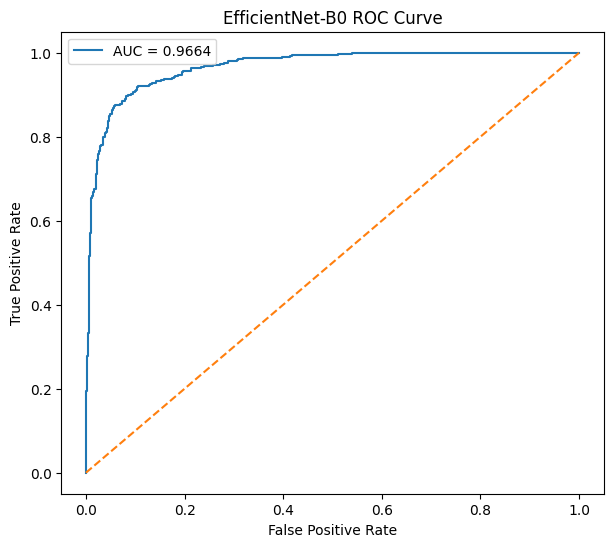

In [41]:

fpr, tpr, thresholds = roc_curve(
    efficientnet_all_labels,
    efficientnet_all_probs
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {efficientnet_auc:.4f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EfficientNet-B0 ROC Curve")

plt.legend()

plt.savefig(f"../outputs/efficientnet_b0_roc_curve_{num_epochs}epoch.png")
plt.show()

20. Final Results CSV

In [42]:

os.makedirs("../outputs/model_results", exist_ok=True)

results_df = pd.DataFrame({
    "Model": ["EfficientNet-B0"],
    "Epoch": [num_epochs],
    "Best Validation Accuracy": [max(efficientnet_valid_accuracies) if len(efficientnet_valid_accuracies) > 0 else np.nan],
    "Final Validation Accuracy": [efficientnet_valid_accuracies[-1] if len(efficientnet_valid_accuracies) > 0 else np.nan],
    "Test Accuracy": [efficientnet_accuracy * 100],
    "Precision": [efficientnet_precision],
    "Recall": [efficientnet_recall],
    "F1-Score": [efficientnet_f1],
    "ROC-AUC": [efficientnet_auc]
})

results_df.to_csv(
    "../outputs/model_results/efficientnet_b0_results.csv",
    index=False
)

results_df

,Model,Epoch,Best Validation Accuracy,Final Validation Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,EfficientNet-B0,5,88.504673,87.663551,88.785047,0.948164,0.820561,0.87976,0.966401
